# 1.导入数据

In [20]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

from sklearn import datasets, linear_model
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm
import pickle
import time
# 绘图
# 1. 确定画布
from matplotlib import pyplot as plt
#新增加的两行
import matplotlib

# 设置英文字体和数字字体


from __future__ import absolute_import, division, print_function
#显示所有列
pd.set_option('display.max_columns', None)
#显示所有行
pd.set_option('display.max_rows',None)
def process_folder(folder_path):
    # Create an empty DataFrame to store the results
    result = pd.DataFrame()

    # Loop through all files in the folder
    for filename in os.listdir(folder_path):
        if filename.endswith(".xlsx"):
            # Read the file and apply the function
            file_path = os.path.join(folder_path, filename)
            data = pd.read_excel(file_path)
            result = pd.concat([result,data], axis=0,ignore_index=False)
            # Append the results to the final DataFrame
#             result = result.insert(data)

    # Return the final DataFrame
    return result

# folder_path1="E:/Master Degree Candidate/research/modis"
#显示所有列
pd.set_option('display.max_columns', None)
#显示所有行
pd.set_option('display.max_rows',None)

# df=process_folder(folder_path1)

########特征提取
#data=pd.read_excel("F:\\A研究生实验\\小论文结果\\小论文1\\数据20240524\\4.特征筛选\\第二次筛选剔除相关性强且原始变量一致后的数据集.xlsx")


###########全时序指数
data=pd.read_excel("F:\\A研究生实验\\小论文结果\\小论文1\\数据20240524\\3-2四省时序指数\\全时序指数.xlsx")

data.head(3)

,code,start,end,yield,NDVI_10.15,NDVI_10.25,NDVI_11.5,NDVI_11.15,NDVI_11.25,NDVI_12.5,NDVI_12.15,NDVI_12.25,NDVI_1.5,NDVI_1.15,NDVI_1.25,NDVI_2.5,NDVI_2.15,NDVI_2.25,NDVI_3.5,NDVI_3.15,NDVI_3.25,NDVI_4.5,NDVI_4.15,NDVI_4.25,NDVI_5.5,NDVI_5.15,NDVI_5.25,NDVI_6.5,NDVI_6.15,NDWI_10.15,NDWI_10.25,NDWI_11.5,NDWI_11.15,NDWI_11.25,NDWI_12.5,NDWI_12.15,NDWI_12.25,NDWI_1.5,NDWI_1.15,NDWI_1.25,NDWI_2.5,NDWI_2.15,NDWI_2.25,NDWI_3.5,NDWI_3.15,NDWI_3.25,NDWI_4.5,NDWI_4.15,NDWI_4.25,NDWI_5.5,NDWI_5.15,NDWI_5.25,NDWI_6.5,NDWI_6.15
0,370725,2015,2016,6715.999999,0.341953,0.340460,0.334918,0.269155,0.305735,0.302158,0.295604,0.274942,0.252238,0.245069,0.239594,0.242097,0.253480,0.270814,0.276040,0.306151,0.328213,0.396587,0.474953,0.546737,0.499367,0.518987,0.454585,0.432897,0.400021,-0.047421,-0.011208,0.005753,0.001716,0.062493,-0.039311,-0.043423,-0.021722,-0.021493,-0.049617,0.005801,-0.043508,0.006417,-0.074458,-0.048374,-0.043557,-0.048035,-0.001518,0.024334,0.047467,0.050918,0.051221,0.049806,0.024783,0.021724
1,370724,2015,2016,5242.999999,0.375347,0.369878,0.358498,0.296607,0.292692,0.289312,0.263847,0.259415,0.240687,0.230785,0.217161,0.228207,0.253511,0.246843,0.254251,0.273886,0.284964,0.394937,0.476332,0.509798,0.502799,0.547322,0.501751,0.477758,0.457783,-0.053985,-0.021462,-0.003602,0.005602,0.086797,-0.050139,-0.061581,-0.028268,-0.017555,-0.046519,-0.002025,-0.046961,-0.020587,-0.093109,-0.046243,-0.058664,-0.063273,-0.011404,0.003995,0.031623,0.031816,0.037841,0.035827,0.022586,0.017999
2,370786,2015,2016,6703.999999,0.338781,0.335779,0.331658,0.252455,0.330124,0.340761,0.327213,0.304967,0.282440,0.271628,0.255782,0.263772,0.272032,0.270716,0.273544,0.312950,0.342119,0.459049,0.517725,0.614858,0.566620,0.593601,0.482482,0.457061,0.346007,-0.043415,-0.022004,0.010013,0.001774,0.026669,-0.042692,-0.031902,-0.015312,-0.018569,-0.041809,-0.049861,-0.042743,-0.006964,-0.080635,-0.052954,-0.033308,-0.040765,0.000231,0.046774,0.067757,0.083890,0.071674,0.080524,0.031816,0.015906


In [21]:
######特征提取
#data.iloc[:, np.r_[3:20]].head(2)
########全时序指数
data.iloc[:, np.r_[3:54]].head(2)

,yield,NDVI_10.15,NDVI_10.25,NDVI_11.5,NDVI_11.15,NDVI_11.25,NDVI_12.5,NDVI_12.15,NDVI_12.25,NDVI_1.5,NDVI_1.15,NDVI_1.25,NDVI_2.5,NDVI_2.15,NDVI_2.25,NDVI_3.5,NDVI_3.15,NDVI_3.25,NDVI_4.5,NDVI_4.15,NDVI_4.25,NDVI_5.5,NDVI_5.15,NDVI_5.25,NDVI_6.5,NDVI_6.15,NDWI_10.15,NDWI_10.25,NDWI_11.5,NDWI_11.15,NDWI_11.25,NDWI_12.5,NDWI_12.15,NDWI_12.25,NDWI_1.5,NDWI_1.15,NDWI_1.25,NDWI_2.5,NDWI_2.15,NDWI_2.25,NDWI_3.5,NDWI_3.15,NDWI_3.25,NDWI_4.5,NDWI_4.15,NDWI_4.25,NDWI_5.5,NDWI_5.15,NDWI_5.25,NDWI_6.5,NDWI_6.15
0,6715.999999,0.341953,0.340460,0.334918,0.269155,0.305735,0.302158,0.295604,0.274942,0.252238,0.245069,0.239594,0.242097,0.253480,0.270814,0.276040,0.306151,0.328213,0.396587,0.474953,0.546737,0.499367,0.518987,0.454585,0.432897,0.400021,-0.047421,-0.011208,0.005753,0.001716,0.062493,-0.039311,-0.043423,-0.021722,-0.021493,-0.049617,0.005801,-0.043508,0.006417,-0.074458,-0.048374,-0.043557,-0.048035,-0.001518,0.024334,0.047467,0.050918,0.051221,0.049806,0.024783,0.021724
1,5242.999999,0.375347,0.369878,0.358498,0.296607,0.292692,0.289312,0.263847,0.259415,0.240687,0.230785,0.217161,0.228207,0.253511,0.246843,0.254251,0.273886,0.284964,0.394937,0.476332,0.509798,0.502799,0.547322,0.501751,0.477758,0.457783,-0.053985,-0.021462,-0.003602,0.005602,0.086797,-0.050139,-0.061581,-0.028268,-0.017555,-0.046519,-0.002025,-0.046961,-0.020587,-0.093109,-0.046243,-0.058664,-0.063273,-0.011404,0.003995,0.031623,0.031816,0.037841,0.035827,0.022586,0.017999


# 2.确定训练集和验证集

In [22]:
# x = data.iloc[1914:, ]
# x
# train_data= data.iloc[:1914,np.r_[0:6,9,10,11,15,16,17,20,6,7] ]
# test_data=data.iloc[1914:,np.r_[0:6,9,10,11,15,16,17,20,6,7] ]
# # 将因变量和自变量分开
# x_train = train_data.iloc[:, 5:]
data_2021_train=data[data['end'].isin([2011,2012,2013,2014,2015,2016,2017,2018,2019,2020])]
data_2021_test=data[data['end'].isin([2021])]

data_2020_train=data[data['end'].isin([2011,2012,2013,2014,2015,2016,2017,2018,2019,2021])]
data_2020_test=data[data['end'].isin([2020])]

data_2019_train=data[data['end'].isin([2011,2012,2013,2014,2015,2016,2017,2018,2020,2021])]
data_2019_test=data[data['end'].isin([2019])]

data_2018_train=data[data['end'].isin([2011,2012,2013,2014,2015,2016,2017,2019,2020,2021])]
data_2018_test=data[data['end'].isin([2018])]

data_2017_train=data[data['end'].isin([2011,2012,2013,2014,2015,2016,2018,2019,2020,2021])]
data_2017_test=data[data['end'].isin([2017])]

data_2016_train=data[data['end'].isin([2011,2012,2013,2014,2015,2017,2018,2019,2020,2021])]
data_2016_test=data[data['end'].isin([2016])]

data_2015_train=data[data['end'].isin([2011,2012,2013,2014,2016,2017,2018,2019,2020,2021])]
data_2015_test=data[data['end'].isin([2015])]

data_2014_train=data[data['end'].isin([2011,2012,2013,2016,2015,2017,2018,2019,2020,2021])]
data_2014_test=data[data['end'].isin([2014])]

data_2013_train=data[data['end'].isin([2011,2012,2016,2014,2015,2017,2018,2019,2020,2021])]
data_2013_test=data[data['end'].isin([2013])]

data_2012_train=data[data['end'].isin([2011,2016,2013,2014,2015,2017,2018,2019,2020,2021])]
data_2012_test=data[data['end'].isin([2012])]

data_2011_train=data[data['end'].isin([2016,2012,2013,2014,2015,2017,2018,2019,2020,2021])]
data_2011_test=data[data['end'].isin([2011])]





data_20_21_train=data[data['end'].isin([2011,2012,2013,2014,2015,2016,2017,2018,2019])]
data_20_21_test=data[data['end'].isin([2020,2021])]
# type(data_2019_train)
data_20_21_test.shape

(769, 54)

In [3]:
data_20_21_train.reset_index(drop=True, inplace=True)
data_20_21_test.reset_index(drop=True, inplace=True)

# 3.相关性分析

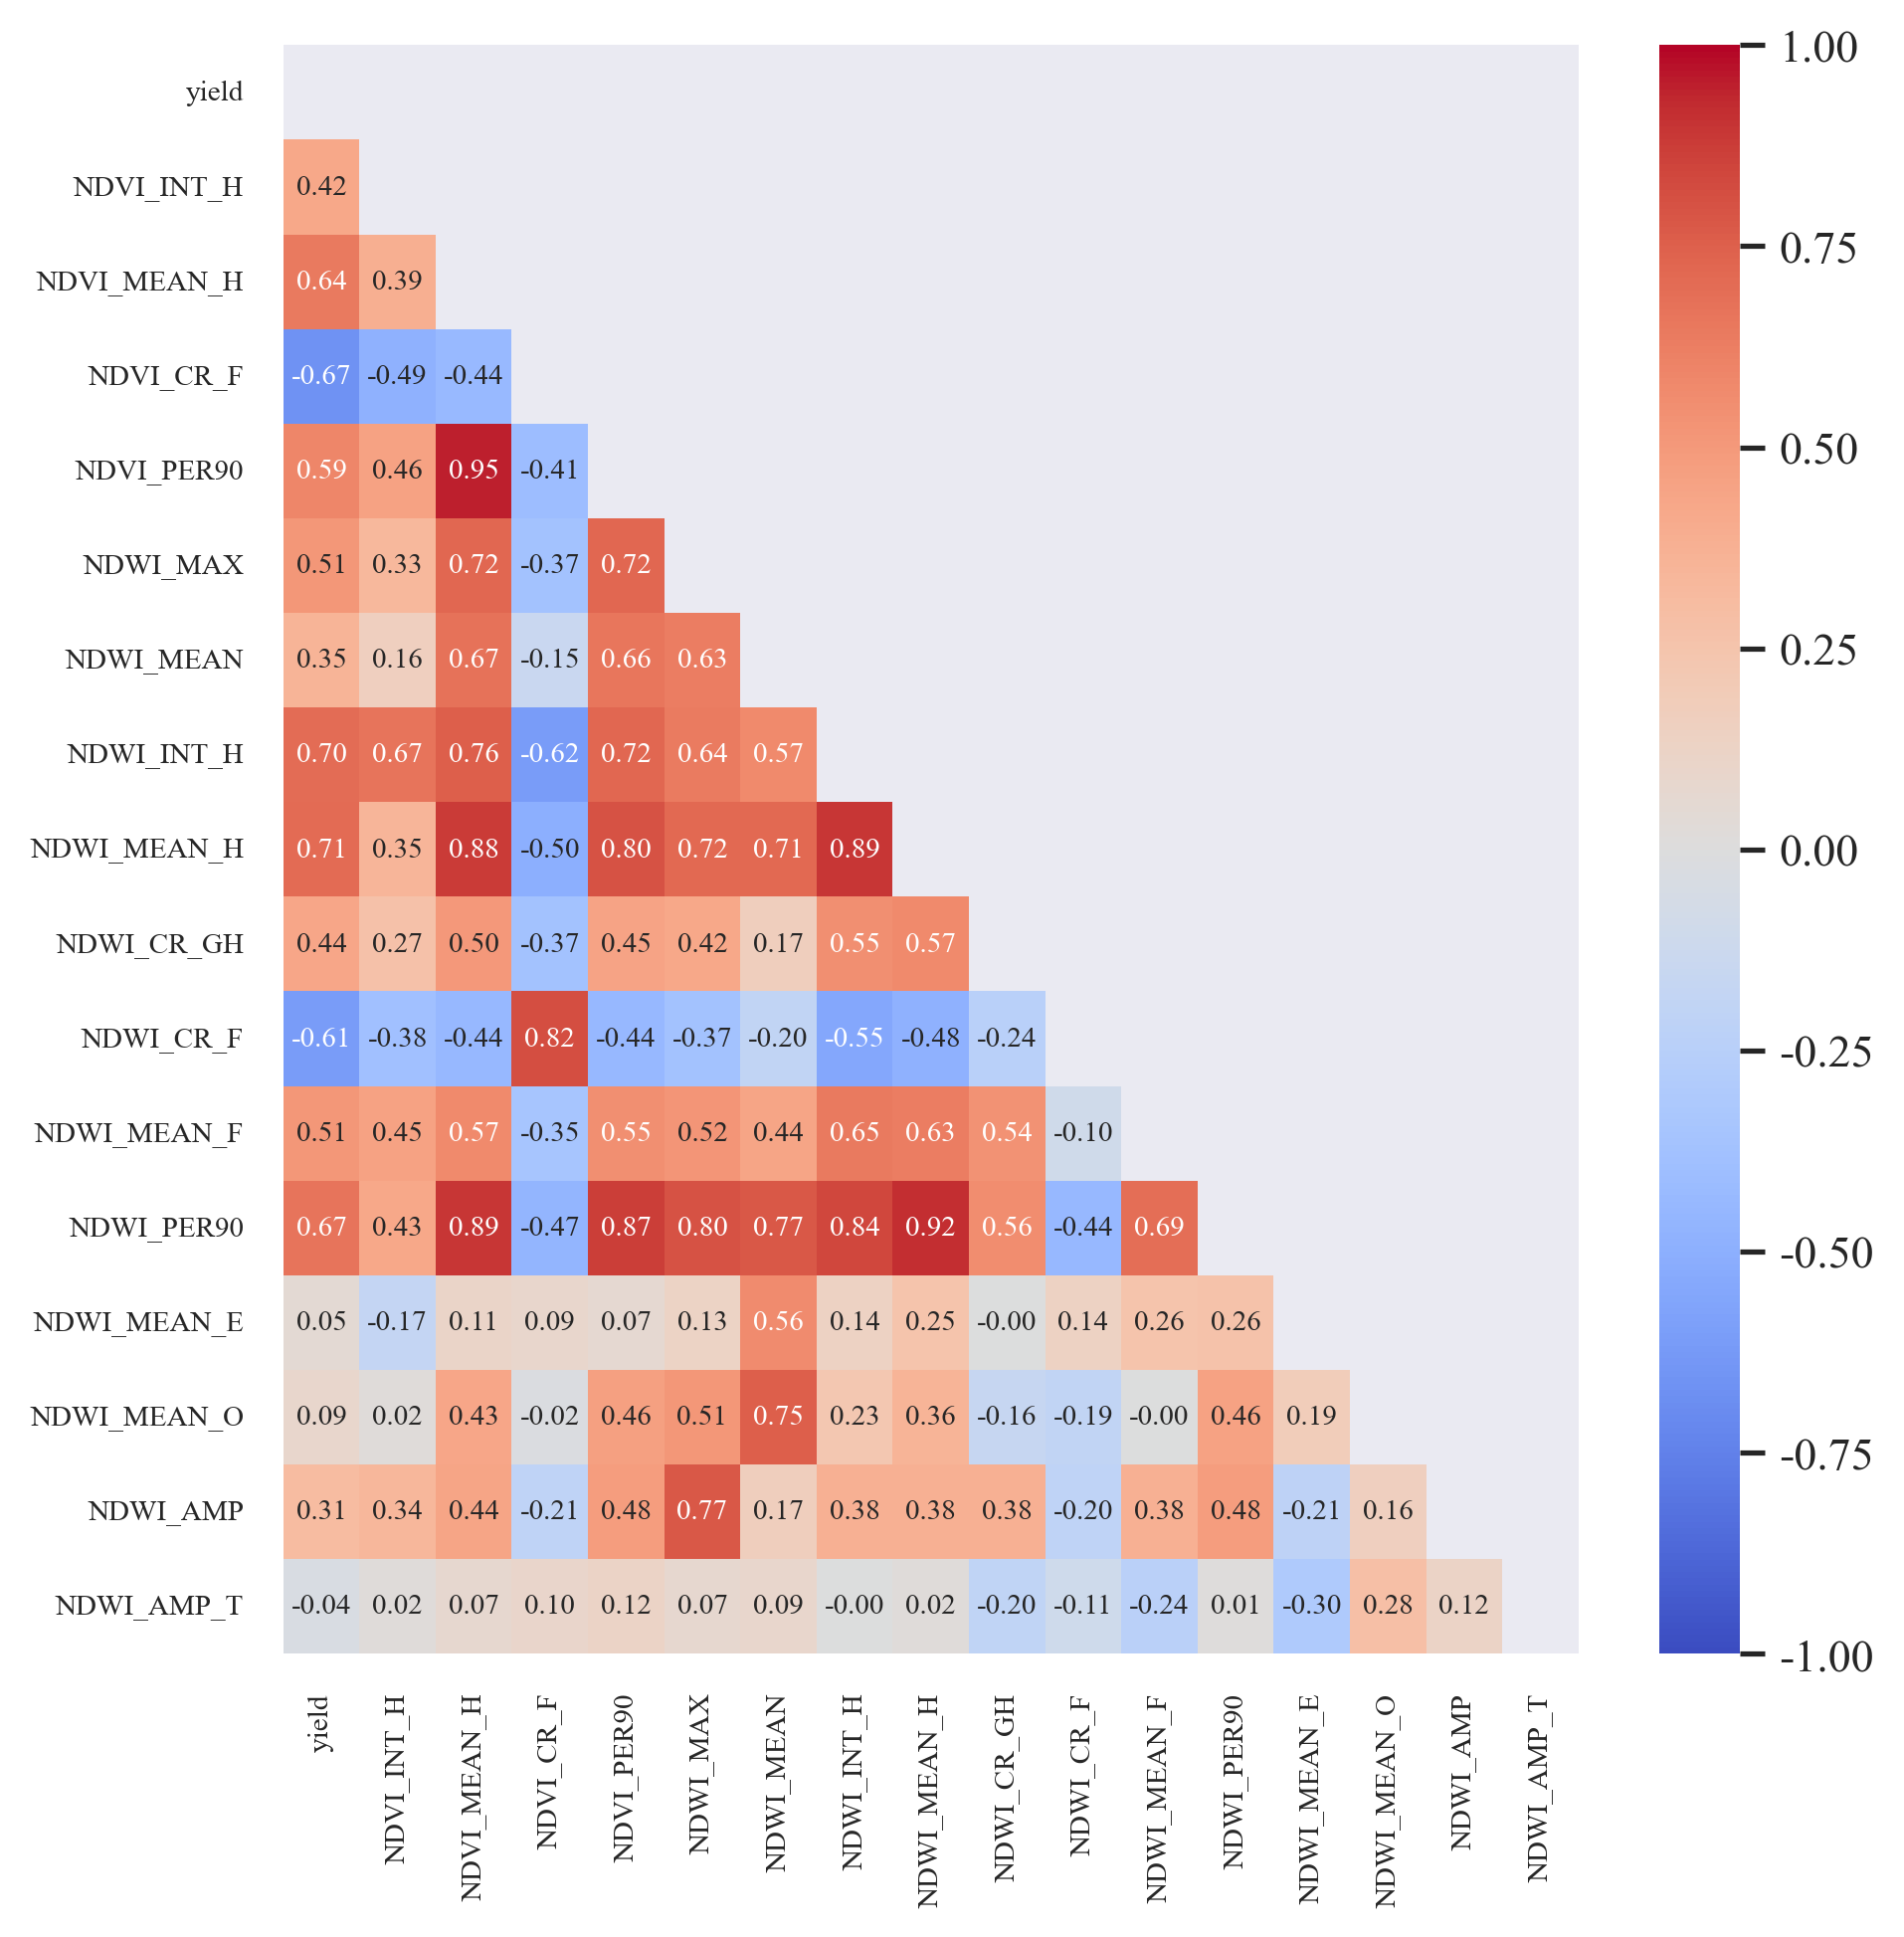

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.set(font='Times New Roman')  # 设置字体
plt.rcParams['axes.unicode_minus'] = False  # 处理负号显示问题

# 使用Spearman方法计算相关矩阵
corr_matrix = data_2021_train.iloc[:, np.r_[3:20]].corr(method='spearman')

plt.figure(dpi=300, figsize=(7, 7))

# 创建掩码，隐藏上三角
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 绘制热力图
heatmap = sns.heatmap(corr_matrix, cmap='coolwarm', annot=True, vmin=-1, vmax=1, center=0, mask=mask,
                      cbar_kws={'ticks': [-1, -0.75, -0.5, -0.25, 0, 0.25, 0.5, 0.75, 1]},
                      annot_kws={"size": 7}, fmt=".2f")

# 设置外围索引的字号为 7 号
heatmap.tick_params(axis='x', labelsize=7)  # 控制 x 轴外围索引的字号
heatmap.tick_params(axis='y', labelsize=7)  # 控制 y 轴外围索引的字号

plt.show()


In [ ]:
sns.set(font='Times New Roman')  #设置画图中的中文为黑体
# SimHei代表黑体
# simsun代表宋体
plt.rcParams['axes.unicode_minus']=False 

corr_matrix = Data.iloc[:, np.r_[1:22]].corr()
plt.figure(dpi=300, figsize=(8, 8))

# 创建掩码，隐藏上三角
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 绘制热力图
heatmap=sns.heatmap(corr_matrix, cmap='coolwarm', annot=True, vmin=-1, vmax=1, center=0, mask=mask,
            cbar_kws={'ticks': [-1, -0.75, -0.5, -0.25, 0, 0.25, 0.5, 0.75, 1]},
            annot_kws={"size": 7}, fmt=".2f")
# 设置外围索引的字号为 9 号
heatmap.tick_params(axis='x', labelsize=7)  # 控制 x 轴外围索引的字号
heatmap.tick_params(axis='y', labelsize=7)  # 控制 y 轴外围索引的字号

plt.show()

In [16]:
# data_jiangsu_test=data_2021_test[data_2021_test['省'].isin(['Jiangsu Province'])]
# data_shandong_test=data_2021_test[data_2021_test['省'].isin(['Shandong Province'])]
# data_henan_test=data_2021_test[data_2021_test['省'].isin(['Henan Province'])]
# data_anhui_test=data_2021_test[data_2021_test['省'].isin(['Anhui Province'])]

# data_jiangsu_train=data_2021_train[data_2021_train['省'].isin(['Jiangsu Province'])]
# data_shandong_train=data_2021_train[data_2021_train['省'].isin(['Shandong Province'])]
# data_henan_train=data_2021_train[data_2021_train['省'].isin(['Henan Province'])]
# data_anhui_train=data_2021_train[data_2021_train['省'].isin(['Anhui Province'])]

# 3.LR回归

训练集的CCC: 0.78
测试集的CCC: 0.76


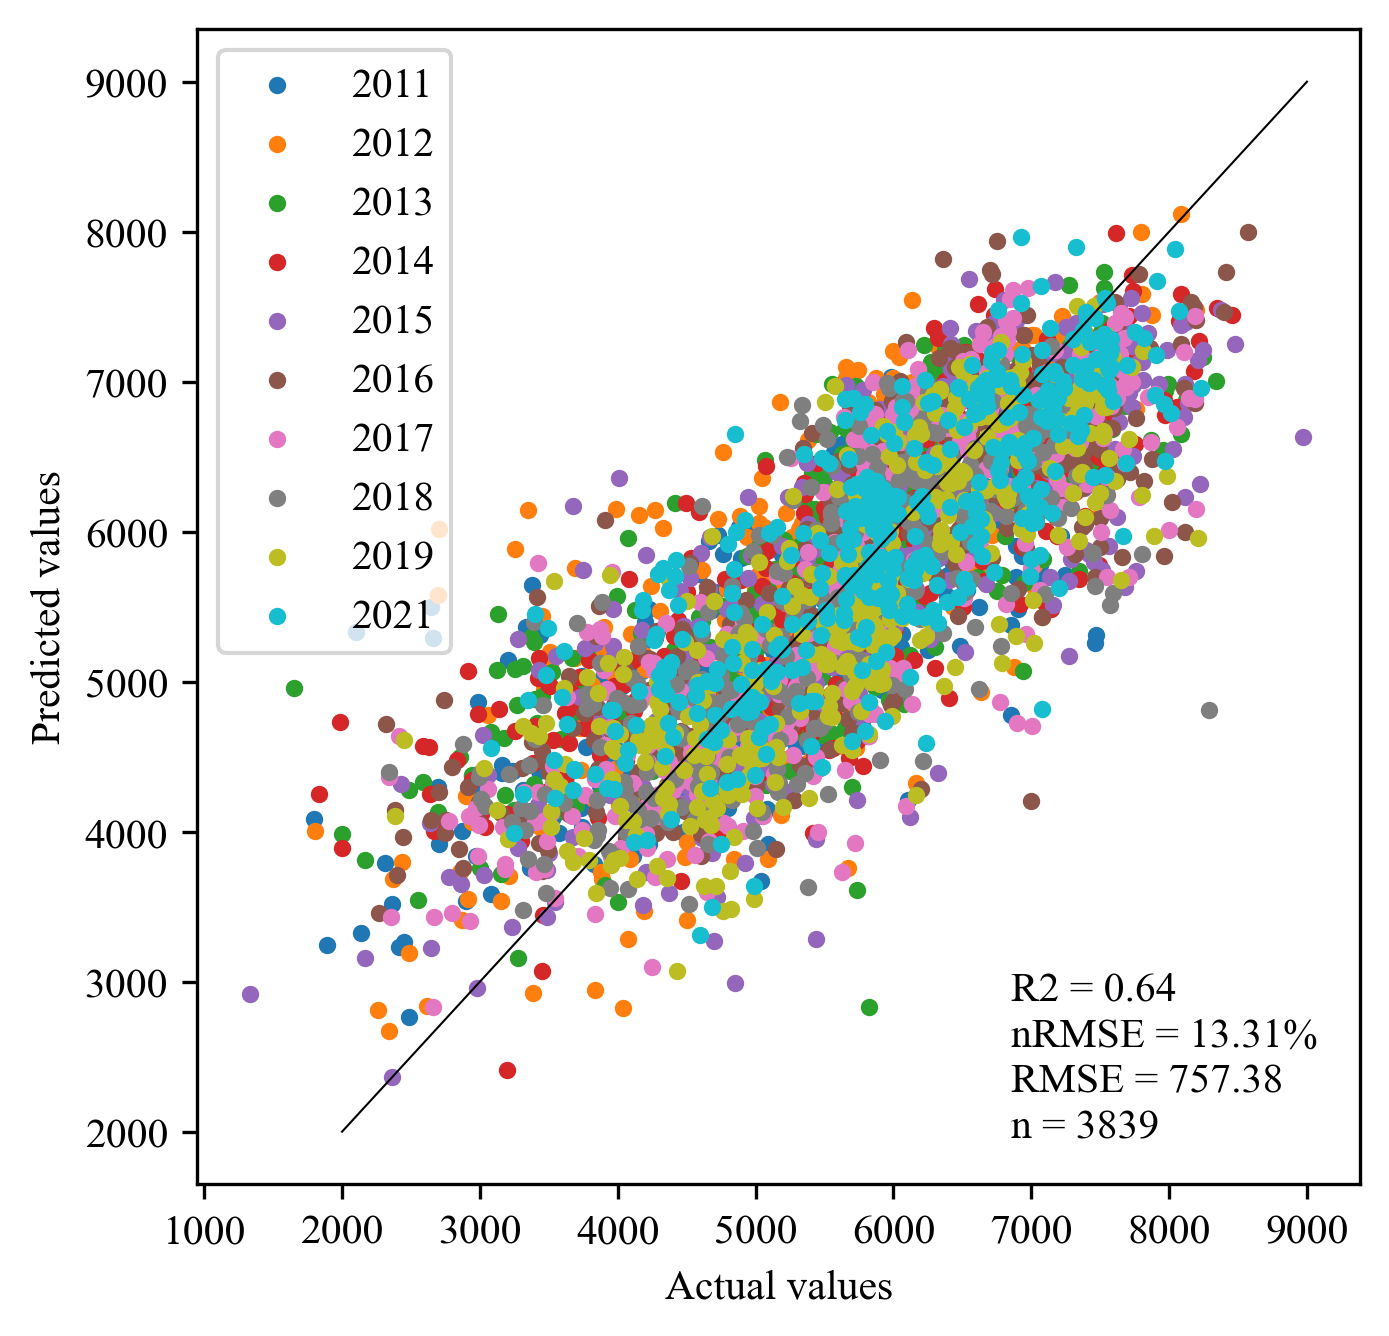

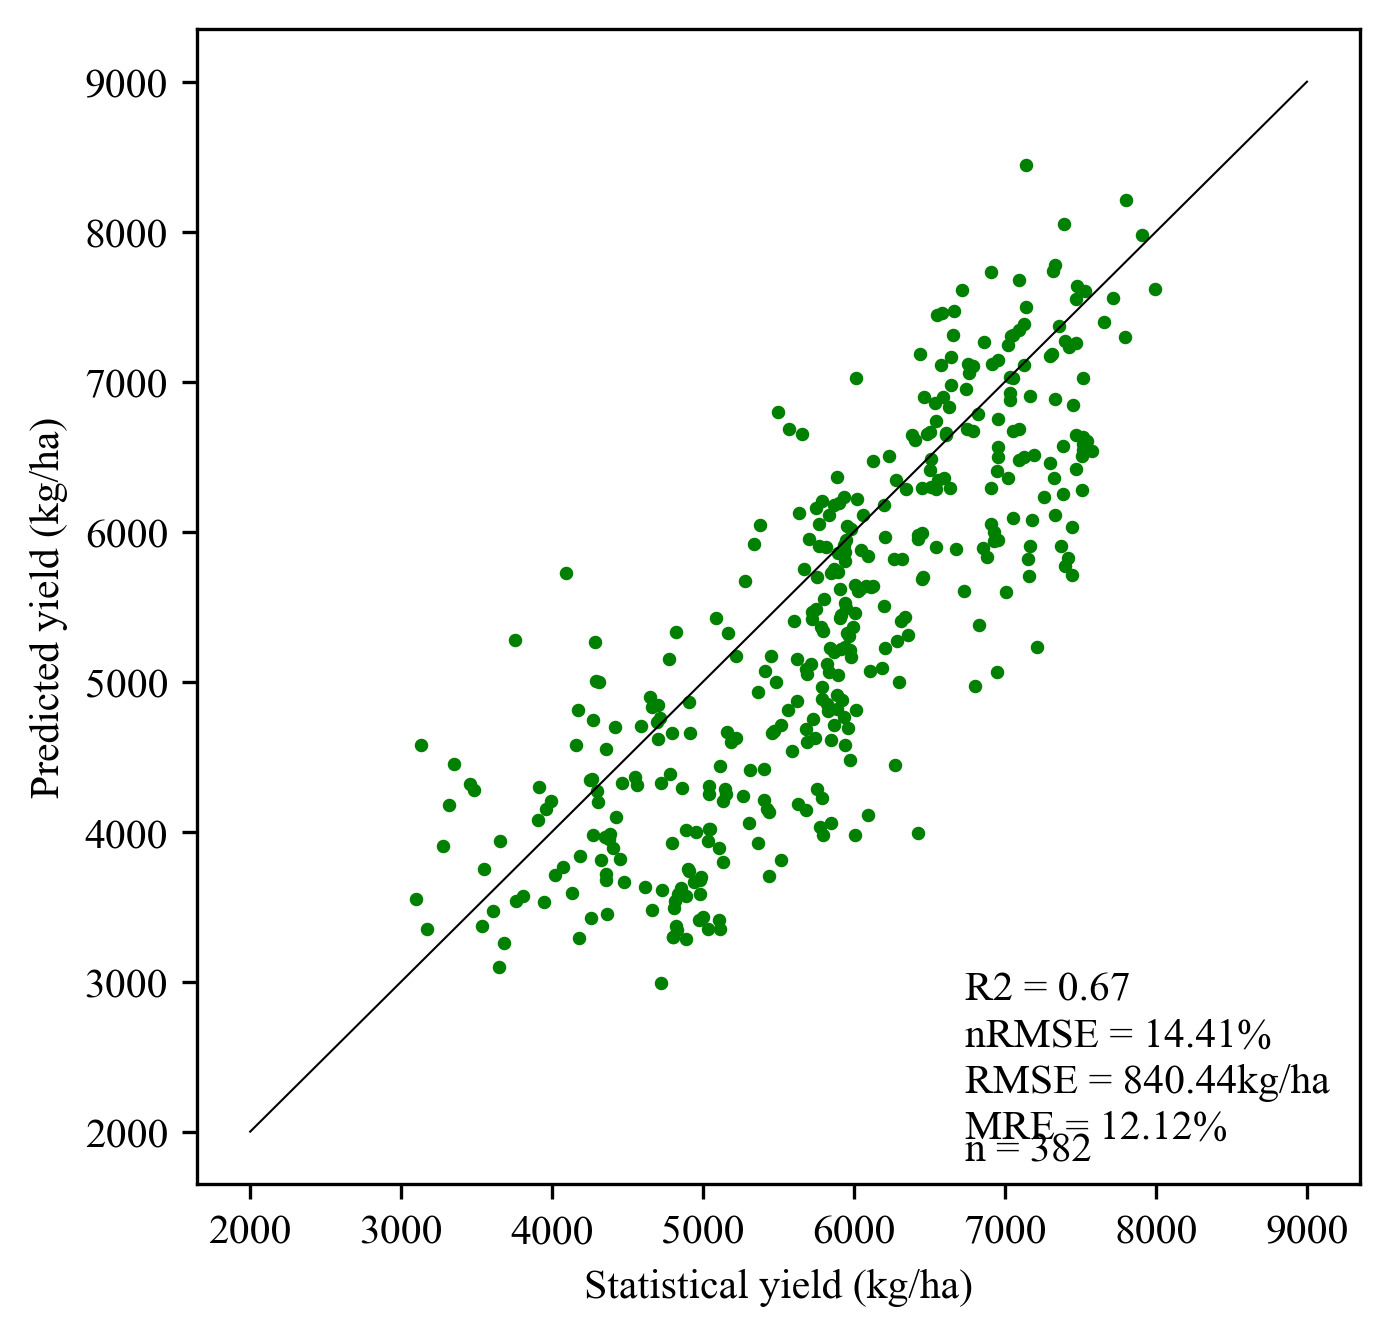

In [33]:
# 导入所需库
from sklearn.preprocessing import StandardScaler
import shap
from sklearn.ensemble import RandomForestRegressor
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from statsmodels.tools.eval_measures import rmse
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import math
from sklearn.cross_decomposition import PLSRegression
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress

# plt.rcParams['font.family'] = ['Microsoft YaHei'] # 将微软雅黑设置为字体族

plt.rcParams['font.family'] = 'Times New Roman'
# matplotlib.rcParams['font.sans-serif'] = ['Times New Roman']
# matplotlib.rc("font",family='FangSong')
df=data
# train_data, test_data = train_test_split(df, test_size=0.3, random_state=32)
train_data= data_2020_train
test_data=data_2020_test

# test_data=data_2021_anhui_test
# 将因变量和自变量分开
################################################################################时序特征
# x_train = train_data.iloc[:, np.r_[4:20]].values
# y_train = train_data.iloc[:, 3].values
# x_test = test_data.iloc[:, np.r_[4:20]].values
# y_test = test_data.iloc[:, 3].values


####################################################################################全时序指数
x_train = train_data.iloc[:, np.r_[4:54]].values
y_train = train_data.iloc[:, 3].values
x_test = test_data.iloc[:, np.r_[4:54]].values
y_test = test_data.iloc[:, 3].values


# 创建模型并训练
regressor = LinearRegression()
regressor.fit(x_train, y_train)

# 预测建模集和验证集结果
y_pred_train = regressor.predict(x_train)
y_pred_test = regressor.predict(x_test)

# 计算建模集和验证集的R^2

# r2_test = r2_score(y_test, y_pred_test)



# Calculate RMSE and nRMSE
rmse_train = rmse(y_pred_train, y_train)
nrmse_train = rmse_train / np.mean(y_train)

rmse_test = rmse(y_pred_test, y_test)
nrmse_test = rmse_test / np.mean(y_test)
#计算建模集和验证集的R
r_test = np.corrcoef(y_test, y_pred_test)[0, 1]
r_train=np.corrcoef(y_train, y_pred_train)[0, 1]
# 计算训练集的CCC
r_train = np.corrcoef(y_train, y_pred_train)[0, 1]
var_y_train = np.var(y_train)
var_y_pred_train = np.var(y_pred_train)
mean_y_train = np.mean(y_train)
mean_y_pred_train = np.mean(y_pred_train)
ccc_train = 2 * r_train * np.sqrt(var_y_train * var_y_pred_train) / (var_y_train + var_y_pred_train + (mean_y_train - mean_y_pred_train)**2)
print(f"训练集的CCC: {ccc_train:.2f}")

# 计算测试集的CCC
r_test = np.corrcoef(y_test, y_pred_test)[0, 1]
var_y_test = np.var(y_test)
var_y_pred_test = np.var(y_pred_test)
mean_y_test = np.mean(y_test)
mean_y_pred_test = np.mean(y_pred_test)
ccc_test = 2 * r_test * np.sqrt(var_y_test * var_y_pred_test) / (var_y_test + var_y_pred_test + (mean_y_test - mean_y_pred_test)**2)
print(f"测试集的CCC: {ccc_test:.2f}")

r2_train = r_train*r_train
r2_test=r_test*r_test

def calculate_mre(y_true, y_pred):
    n = len(y_true)
    mre = (1/n) * np.sum(np.abs((y_true - y_pred) / np.abs(y_true)))
    return mre

mre = calculate_mre(y_test, y_pred_test)
year_train = sorted(train_data['end'].unique())
# 创建一个新的图形并设置其大小
fig, ax = plt.subplots(figsize=(5, 5),dpi=300)
# 绘制建模集散点图
# ax.scatter(y_train, y_pred_train)
for year in year_train:
    train_data_year = train_data[train_data['end'] == year]
    y_train_year = y_train[train_data['end'] == year]
    y_pred_train_year = y_pred_train[train_data['end'] == year]
    ax.scatter(y_train_year, y_pred_train_year, s=10,label=year)
ax.set_xlabel('Actual values')
ax.set_ylabel('Predicted values')
# ax.set_title('train data')

# ax.set(facecolor = "white")#修改背景图颜色
# 显示其他信息
# ax.text(0.75, 0.2, 'R^2 = {:.3f}'.format(r2_train), transform=ax.transAxes)
ax.text(0.7, 0.16, 'R2 = {:.2f}'.format(r2_train), transform=ax.transAxes)
ax.text(0.7, 0.12, 'nRMSE = {:.2%}'.format(nrmse_train), transform=ax.transAxes)
ax.text(0.7, 0.08, 'RMSE = {:.2f}'.format(rmse_train), transform=ax.transAxes)
# 添加点的个数标注
n = len(y_train)
ax.text(0.7, 0.04, f'n = {n}', transform=ax.transAxes)
# 计算趋势线的斜率和截距
slope, intercept = np.polyfit(y_train, y_pred_train, 1)
# 绘制趋势线
# ax.plot(y_train, slope * np.array(y_train) + intercept, color='red', label='Trendline')
# 绘制1:1线
ax.plot([2000, 9000], [2000, 9000], ls='-', c='k',linewidth=0.5)
# 添加图例
ax.legend()
# 显示图形
plt.show()


##############验证集##########
year_test = sorted(test_data['end'].unique())
# 创建一个新的图形并设置其大小
fig, ax = plt.subplots(figsize=(5, 5),dpi=300)
#分色绘制散点图
for year in year_test:
    test_data_year = test_data[test_data['end'] == year]
    y_test_year = y_test[test_data['end'] == year]
    y_pred_test_year = y_pred_test[test_data['end'] == year]
    ax.scatter(y_test_year, y_pred_test_year, c='green',s=5,label=year)
# 绘制验证集散点图
# ax.scatter(y_test, y_pred_test)
ax.set_xlabel('Statistical yield (kg/ha)')
ax.set_ylabel('Predicted yield (kg/ha)')
# ax.set_title('test data')
# 显示其他信息
# ax.text(0.75, 0.2, 'R^2 = {:.3f}'.format(r2_test), transform=ax.transAxes)

ax.text(0.66, 0.16, 'R2 = {:.2f}'.format(r2_test), transform=ax.transAxes,size=10)
ax.text(0.66, 0.12, 'nRMSE = {:.2%}'.format(nrmse_test), transform=ax.transAxes,size=10)
ax.text(0.66, 0.08, 'RMSE = {:.2f}kg/ha'.format(rmse_test), transform=ax.transAxes,size=10)
ax.text(0.66, 0.04, 'MRE = {:.2%}'.format(mre), transform=ax.transAxes,size=10)
# 添加点的个数标注
n = len(y_test)
ax.text(0.66, 0.02, f'n = {n}', transform=ax.transAxes,size=10)
# 计算趋势线的斜率和截距
slope, intercept = np.polyfit(y_test, y_pred_test, 1)
# 绘制趋势线
# ax.plot(y_test, slope * np.array(y_test) + intercept, color='red', label='Trendline')
# 绘制1:1线
ax.plot([2000, 9000], [2000, 9000], ls='-', c='k',linewidth=0.5)
# 添加图例
# ax.legend()
# 显示图形
plt.show()

# ##################带有标注的分省分色绘制散点验证集图##########################
# province_test = sorted(test_data['省'].unique())
# # 创建一个新的图形并设置其大小
# fig, ax = plt.subplots(figsize=(8, 8))
# #分色绘制散点图
# for year in province_test:
#     test_data_year = test_data[test_data['省'] == year]
#     y_test_year = y_test[test_data['省'] == year]
#     y_pred_test_year = y_pred_test[test_data['省'] == year]
#     ax.scatter(y_test_year, y_pred_test_year, label=year)
#     for i, txt in enumerate(test_data_year['ENG_NAME']):
#         ax.annotate(txt, (y_test_year[i], y_pred_test_year[i]),fontsize=6)
# # 绘制验证集散点图
# # ax.scatter(y_test, y_pred_test)
# ax.set_xlabel('Actual values')
# ax.set_ylabel('Predicted values')
# ax.set_title('test data标注')
# # 显示其他信息
# # ax.text(0.75, 0.2, 'R^2 = {:.3f}'.format(r2_test), transform=ax.transAxes)
# ax.text(0.75, 0.16, 'R = {:.3f}'.format(r_test), transform=ax.transAxes)
# ax.text(0.75, 0.12, 'nRMSE = {:.2%}'.format(nrmse_test), transform=ax.transAxes)
# ax.text(0.75, 0.08, 'RMSE = {:.2f}'.format(rmse_test), transform=ax.transAxes)
# # 添加点的个数标注
# n = len(y_test)
# ax.text(0.75, 0.04, f'n = {n}', transform=ax.transAxes)
# # 计算趋势线的斜率和截距
# slope, intercept = np.polyfit(y_test, y_pred_test, 1)
# # 绘制趋势线
# ax.plot(y_test, slope * np.array(y_test) + intercept, color='red')
# # 绘制1:1线
# ax.plot(y_test, y_test, color='green', linestyle='--')
# # 添加图例
# ax.legend(loc="upper left")
# # 显示图形
# plt.show()


#############按照省份分色绘图##########################
# province_test = sorted(test_data['省'].unique())
# province_test
# # 创建一个新的图形并设置其大小
# fig, ax = plt.subplots(figsize=(5, 5),dpi=300)
# #分色绘制散点图
# for year in province_test:
#     test_data_year = test_data[test_data['省'] == year]
#     y_test_year = y_test[test_data['省'] == year]
#     y_pred_test_year = y_pred_test[test_data['省'] == year]
#     ax.scatter(y_test_year, y_pred_test_year, s=5,label=year)
# # 绘制验证集散点图
# ax.set_xlabel('Statistical yield (kg/ha)')
# ax.set_ylabel('Predicted yield (kg/ha)')
# # ax.set_title('test data')
# # 显示其他信息
# # ax.text(0.75, 0.2, 'R^2 = {:.3f}'.format(r2_test), transform=ax.transAxes)
# ax.text(0.66, 0.16, 'R = {:.2f}'.format(r_test), transform=ax.transAxes,size=10)
# ax.text(0.66, 0.12, 'nRMSE = {:.2%}'.format(nrmse_test), transform=ax.transAxes,size=10)
# ax.text(0.66, 0.08, 'RMSE = {:.2f}kg/ha'.format(rmse_test), transform=ax.transAxes,size=10)
# # 添加点的个数标注
# n = len(y_test)
# ax.text(0.66, 0.04, f'n = {n}', transform=ax.transAxes,size=10)
# # 计算趋势线的斜率和截距
# slope, intercept = np.polyfit(y_test, y_pred_test, 1)
# # 绘制趋势线
# # ax.plot(y_test, slope * np.array(y_test) + intercept, color='red', label='Trendline')
# # 绘制1:1线
# ax.plot([2000, 9000], [2000, 9000], ls='-', c='k',linewidth=0.5)
# # 添加图例
# ax.legend()
# # 显示图形
# plt.show()
# 使用 SHAP 来解释模型


In [5]:
train_data['pre_LR_train'] = np.nan
train_data.loc[train_data.index, 'pre_LR_train'] = y_pred_train
test_data['pre_LR'] = np.nan
test_data.loc[test_data.index, 'pre_LR'] =y_pred_test
#Write filtered data to new Excel file
train_data.to_excel('LR_train_20_21.xlsx', index=False)
test_data.to_excel('LR_test_20_21.xlsx', index=False)


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


In [7]:
train_data.head(2)

,code,start,end,yield,NDVI_INT_H,NDVI_MEAN_H,NDVI_CR_F,NDVI_PER90,NDWI_MAX,NDWI_MEAN,NDWI_INT_H,NDWI_MEAN_H,NDWI_CR_GH,NDWI_CR_F,NDWI_MEAN_F,NDWI_PER90,NDWI_MEAN_E,NDWI_MEAN_O,NDWI_AMP,NDWI_AMP_T,pre_LR_train
0,370725,2015,2016,6715.999999,1.543074,0.510011,-0.086089,0.489601,0.062493,-0.005649,0.136162,0.043485,0.044804,-0.026438,0.041936,0.050473,0.002267,-0.025857,0.112109,121,6026.836961
1,370724,2015,2016,5242.999999,1.524425,0.509063,-0.069564,0.502380,0.086797,-0.014052,0.084357,0.026319,0.058428,-0.015255,0.032085,0.034223,0.002670,-0.034204,0.148378,152,5699.840429


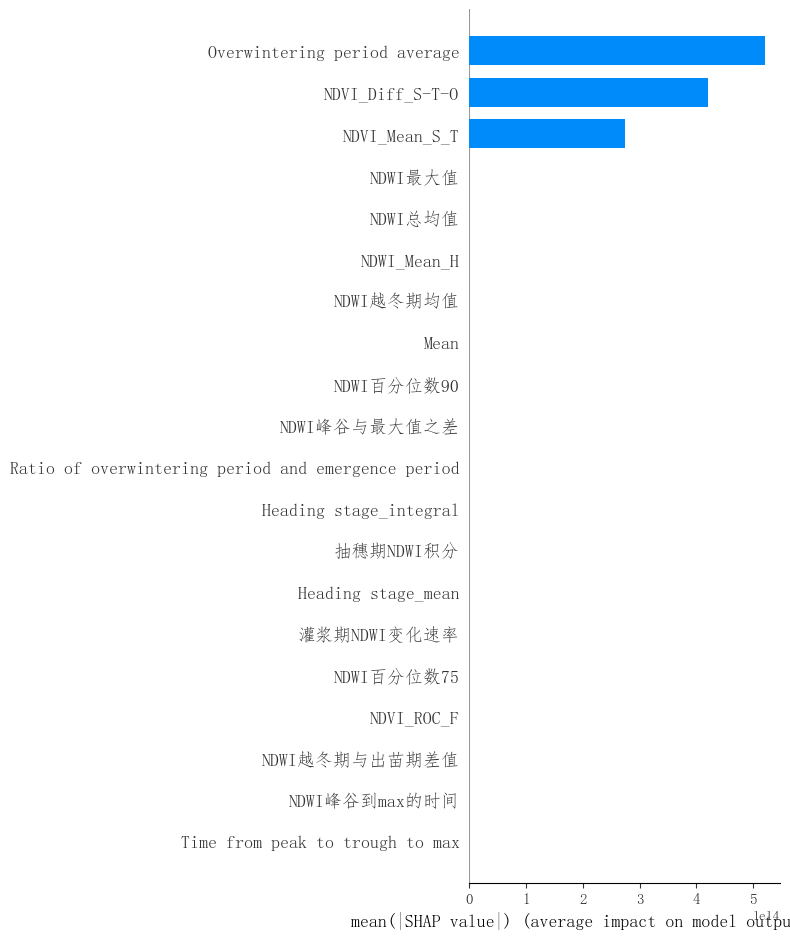

In [38]:
plt.rcParams['axes.unicode_minus'] =False
matplotlib.rc("font",family='FangSong')

explainer = shap.Explainer(regressor, x_train_scaled)

# 计算训练集的SHAP值
shap_values = explainer(x_train_scaled)

# 绘制SHAP值的摘要
shap.summary_plot(shap_values, x_train_scaled, feature_names=train_data.columns[5:35],plot_type='bar')


plt.show()


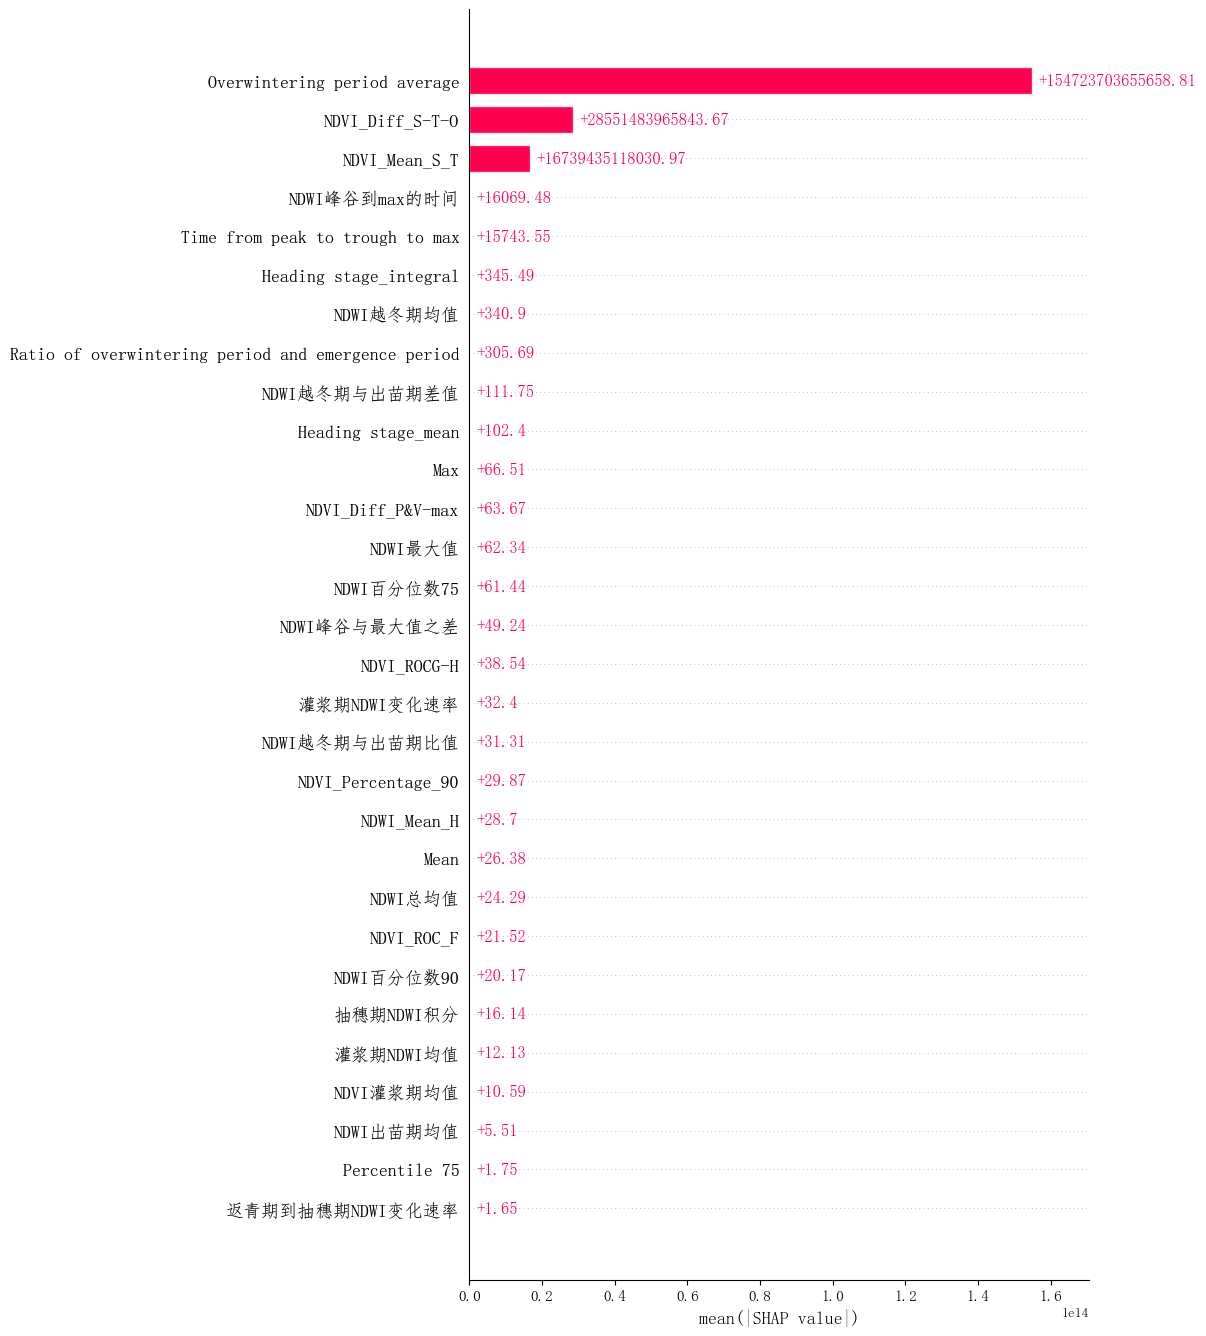

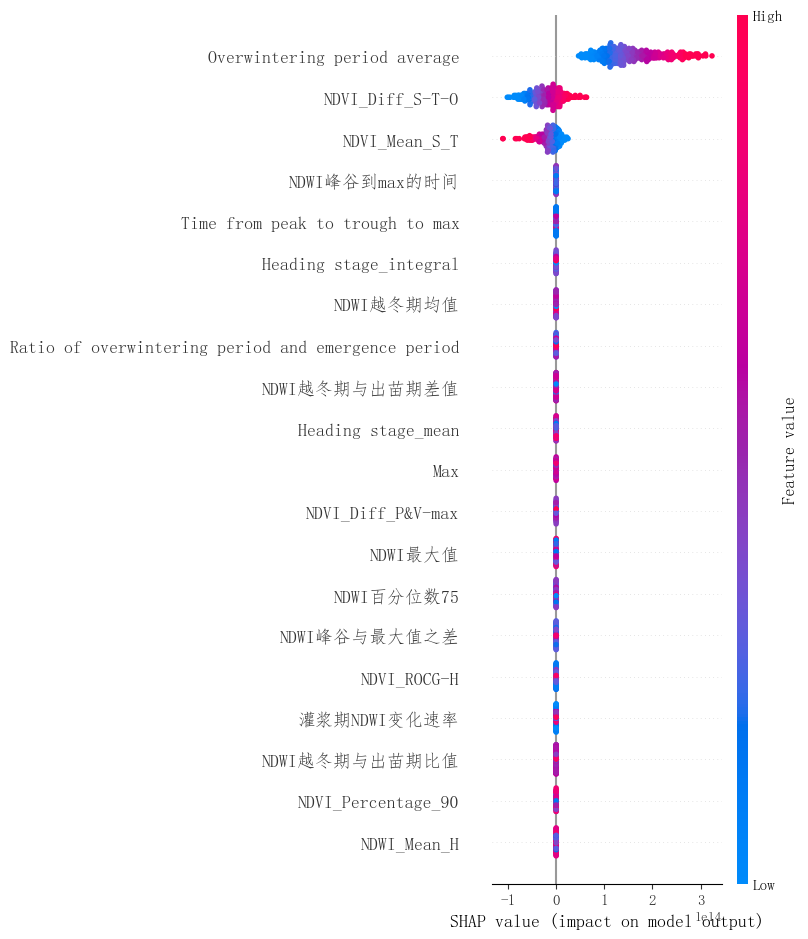

In [20]:
import shap
plt.rcParams['axes.unicode_minus'] =False
# explainer = shap.Explainer(rf_model, X_train)
# shap_values = explainer.shap_values(X_val)
# shap.summary_plot(shap_values, X_val,plot_type="bar")
# 创建包含特征数据的 DataFrame

matplotlib.rc("font",family='FangSong')
df_val = pd.DataFrame(x_test, columns=test_data.columns[np.r_[5:35]])

explainer = shap.Explainer(regressor,x_test_scaled)
shap_values = explainer(x_test_scaled)
# # shap.plots.beeswarm(shap_values)
# shap.plots.bar(shap_values,max_display =30)
shap.summary_plot(shap_values, features=x_test_scaled, feature_names=train_data.columns[np.r_[5:35]])

In [12]:
# train_data['pre_LR_train2016'] = np.nan
# train_data.loc[train_data.index, 'pre_LR_train2016'] = y_pred_train
# test_data['pre_LR2016'] = np.nan
# test_data.loc[test_data.index, 'pre_LR2016'] = y_pred_test
# #Write filtered data to new Excel file
# train_data.to_excel('训练集追加LR预测值2016.xlsx', index=False)
# test_data.to_excel('测试集追加LR预测值2016.xlsx', index=False)

In [20]:
train_data.shape

(1914, 41)

In [4]:
data_2021_train.reset_index(drop=True, inplace=True)
data_2021_test.reset_index(drop=True, inplace=True)

In [11]:
val_data

,code,ENG_NAME,startyear,year,yield,Heading stage_mean,Heading stage_integral,Mean,Max,Change rate from greening stage to heading stage,Grain filling period change rate,The difference between peak and valley and maximum value,Vegetative growth phase change rate,Time from peak to trough to max,Average value during grouting period,Greening stage-joining stage change rate,Percentile 75,Percentile 90,Average value at emergence stage,Overwintering period average,Difference between overwintering period and emergence period,Ratio of overwintering period and emergence period,生殖生长期NDVI变化速率,抽穗期NDWI均值,抽穗期NDWI积分,NDWI总均值,NDWI最大值,返青期到抽穗期NDWI变化速率,灌浆期NDWI变化速率,NDWI峰谷与最大值之差,营养生长期NDWI变化速率,NDWI峰谷到max的时间,灌浆期NDWI均值,返青期-拔节期NDWI变化速率,NDWI百分位数75,NDWI百分位数90,NDWI出苗期均值,NDWI越冬期均值,NDWI越冬期与出苗期差值,NDWI越冬期与出苗期比值,生殖生长期NDWI变化速率,省,pre_RF_1,pre_RF_2,pre_RF_3,pre_RF_4,pre_RF_5,pre_RF_6,pre_RF_7,pre_RF_8,pre_RF_9,pre_RF_10,pre_RF_11,pre_RF_12,pre_RF_13,pre_RF_14,pre_RF_15,pre_RF_16,pre_RF_17,pre_RF_18,pre_RF_19,pre_RF_20,pre_RF_21,pre_RF_22,pre_RF_23,pre_RF_24,pre_RF_25,pre_RF_26,pre_RF_27,pre_RF_28,pre_RF_29,pre_RF_30,pre_LR_1,pre_LR_2,pre_LR_3,pre_LR_4,pre_LR_5,pre_LR_6,pre_LR_7,pre_LR_8,pre_LR_9,pre_LR_10,pre_LR_11,pre_LR_12,pre_LR_13,pre_LR_14,pre_LR_15,pre_LR_16,pre_LR_17,pre_LR_18,pre_LR_19,pre_LR_20,pre_LR_21,pre_LR_22,pre_LR_23,pre_LR_24,pre_LR_25,pre_LR_26,pre_LR_27,pre_LR_28,pre_LR_29,pre_LR_30
0,415099,济源市,2020,2021,6035.747021,0.610345,1.219689,0.428417,0.615604,0.002661,0.137651,0.335785,0.002224,151,0.051589,0.058267,0.516875,0.605246,0.325487,0.371346,-0.045859,0.876505,0.004318,0.070000,0.150000,0.020000,0.090000,0.000000,0.060000,0.120000,0.000000,151,0.030000,0.030000,0.040000,0.070000,0.000000,-0.020000,0.020000,-0.150000,0.000000,Henan Province,5396.206631,5379.834955,5375.799537,5358.343303,5375.248624,5372.287557,5384.986480,5378.688690,5370.326113,5369.473496,5393.931369,5407.541368,5405.330976,5402.312620,5346.128221,5401.421947,5435.728386,5399.265121,5414.767887,5390.042459,5397.116221,5380.906573,5389.204966,5385.955088,5357.505269,5388.256844,5378.244912,5381.301330,5372.871906,5371.676483,5396.206631,5379.834955,5375.799537,5358.343303,5375.248624,5372.287557,5384.986480,5378.688690,5370.326113,5369.473496,5393.931369,5407.541368,5405.330976,5402.312620,5346.128221,5401.421947,5435.728386,5399.265121,5414.767887,5390.042459,5397.116221,5380.906573,5389.204966,5385.955088,5357.505269,5388.256844,5378.244912,5381.301330,5372.871906,5371.676483
1,411528,息县,2020,2021,5352.000000,0.730102,1.446661,0.547963,0.758254,0.001468,0.139776,0.283869,0.001880,151,0.048668,0.045633,0.691370,0.744678,0.431219,0.556776,-0.125557,0.774493,0.010982,0.100000,0.200000,0.030000,0.120000,0.000000,0.110000,0.150000,0.000000,151,0.040000,0.000000,0.070000,0.090000,-0.010000,0.020000,-0.030000,-0.410000,0.000000,Henan Province,6481.303919,6487.858296,6391.748891,6362.130086,6444.024238,6464.667991,6437.549260,6421.993586,6411.184988,6377.288827,6413.168299,6416.286065,6404.677929,6458.234195,6442.759440,6453.095400,6463.140261,6391.945593,6449.169785,6450.324486,6465.240174,6432.264357,6443.478478,6412.420180,6424.719390,6430.177646,6449.631407,6436.751549,6441.527588,6431.678870,6481.303919,6487.858296,6391.748891,6362.130086,6444.024238,6464.667991,6437.549260,6421.993586,6411.184988,6377.288827,6413.168299,6416.286065,6404.677929,6458.234195,6442.759440,6453.095400,6463.140261,6391.945593,6449.169785,6450.324486,6465.240174,6432.264357,6443.478478,6412.420180,6424.719390,6430.177646,6449.631407,6436.751549,6441.527588,6431.678870
2,411422,睢县,2020,2021,7398.438855,0.732315,1.461639,0.531926,0.741682,0.002329,0.231231,0.320949,0.003566,90,0.091787,0.060605,0.618703,0.717458,0.453639,0.504833,-0.051194,0.898593,0.010230,0.100000,0.200000,0.040000,0.140000,0.000000,0.080000,0.150000,0.000000,90,0.040000,0.000000,0.080000,0.100000,0.010000,0.020000,-0.010000,0.640000,0.000000,Henan Province,6356.633832,6348.186090,6321.141197,6309.523481,6366.404887,6365.472096,6332

In [12]:
#Write filtered data to new Excel file
val_data.to_excel('迭代30次追加LR预测值-验证集.xlsx', index=False)
train_data.to_excel('迭代30次追加LR预测值-训练集+测试集.xlsx', index=False)